# 4. Other functions

Recreates the README's "4. Other functions" figures: `get_depths`,
`seabed_area`, `assign_areas`, `project_data`, `get_c_intersection`,
`get_iso_polys`, `rotate_obj`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

import ccamlrgis as cg
import ccamlrgis.plot as cgplot
from ccamlrgis import datasets

depth_cmap = ListedColormap(cg.DEPTH_COLS)
depth_norm = BoundaryNorm(cg.DEPTH_CUTS, depth_cmap.N)
point_data = datasets.load_example("PointData")
bathy_small = cg.small_bathy()

## 4.1. get_depths

         Lat         Lon      Catch
0 -68.639661 -175.007788  53.330017
1 -67.034745 -178.032194  38.663853
2 -65.441637 -170.165640  20.326081
3 -68.368064  151.024697  69.812011
4 -63.891712  154.432712  52.321010
         Lat         Lon      Catch            d
0 -68.639661 -175.007788  53.330017 -3747.237549
1 -67.034745 -178.032194  38.663853 -3937.669922
2 -65.441637 -170.165640  20.326081 -2996.770752
3 -68.368064  151.024697  69.812011  -336.256226
4 -63.891712  154.432712  52.321010 -3237.830322


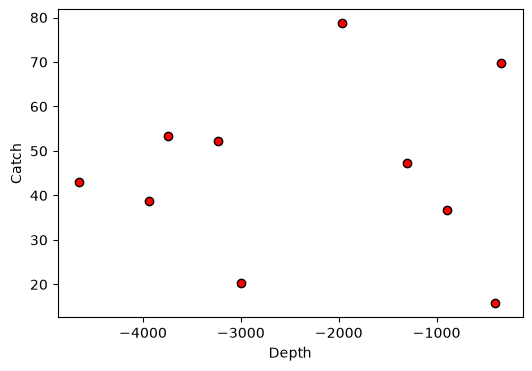

In [2]:
my_data = point_data[["Lat", "Lon", "Catch"]]
print(my_data.head())

my_data_d = cg.get_depths(my_data, bathy_small)
print(my_data_d.head())

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(my_data_d["d"], my_data_d["Catch"], facecolor="red", edgecolor="black")
ax.set_xlabel("Depth")
ax.set_ylabel("Catch")
plt.show()

## 4.2. seabed_area

In [3]:
poly_data = datasets.load_example("PolyData")
my_polys = cg.create_polys(poly_data, densify=True)
# Note the 600-1800 stratum is renamed 'Fishable_area', matching R
fish_depth = cg.seabed_area(bathy_small, my_polys, poly_names="ID", depth_classes=[0, -200, -600, -1800, -3000, -5000])
fish_depth.head()

,ID,0|-200,-200|-600,Fishable_area,-1800|-3000,-3000|-5000
0,one,0.0,19600.0,41300.0,40500.0,93200.0
1,two,0.0,200.0,2000.0,9400.0,94600.0
2,three,700.0,1400.0,8100.0,231800.0,135700.0


## 4.3. assign_areas

In [4]:
rng = np.random.default_rng(0)
my_data = pd.DataFrame({
    "Lat": rng.uniform(-65, -50, 100),
    "Lon": rng.uniform(20, 40, 100),
})
print(my_data.head())

asds = cg.load_asds()
ssrus = cg.load_ssrus()

my_data = cg.assign_areas(my_data, polys={"ASDs": asds, "SSRUs": ssrus}, names_out=["MyASDs", "MySSRUs"])
print(my_data.head())

print(my_data["MyASDs"].value_counts())
print(my_data["MySSRUs"].value_counts())

         Lat        Lon
0 -55.445575  29.599758
1 -60.953199  24.647458
2 -64.385397  36.037612
3 -64.752085  38.470603
4 -52.800946  25.322605


         Lat        Lon  MyASDs   MySSRUs
0 -55.445575  29.599758    48.6    48.6 G
1 -60.953199  24.647458    48.6    48.6 F
2 -64.385397  36.037612  58.4.2  58.4.2 A
3 -64.752085  38.470603  58.4.2  58.4.2 A
4 -52.800946  25.322605    48.6    48.6 G
MyASDs
58.4.4a    47
48.6       44
58.4.2      9
Name: count, dtype: int64
MySSRUs
58.4.4a D    47
48.6 G       30
48.6 F       14
58.4.2 A      9
Name: count, dtype: int64


## 4.4. project_data

In [5]:
print(point_data.head())

my_data = cg.project_data(point_data, names_in=["Lat", "Lon"], names_out=["Projected_Y", "Projected_X"], append=True)
my_data.head()

         Lat         Lon   name      Catch  Nfishes  n
0 -68.639661 -175.007788    one  53.330017    460.0  1
1 -67.034745 -178.032194    two  38.663853    945.0  2
2 -65.441637 -170.165640    two  20.326081    374.0  3
3 -68.368064  151.024697    two  69.812011     87.0  4
4 -63.891712  154.432712  three  52.321010    552.0  5


,Lat,Lon,name,Catch,Nfishes,n,Projected_Y,Projected_X
0,-68.639661,-175.007788,one,53.330017,460.0,1,-2.361962e+06,-2.063214e+05
1,-67.034745,-178.032194,two,38.663853,945.0,2,-2.545119e+06,-8.744572e+04
2,-65.441637,-170.165640,two,20.326081,374.0,3,-2.680488e+06,-4.646563e+05
3,-68.368064,151.024697,two,69.812011,87.0,4,-2.100218e+06,1.162987e+06
4,-63.891712,154.432712,three,52.321010,552.0,5,-2.606157e+06,1.246832e+06


## 4.5. get_C_intersection\n\n`get_c_intersection` (this port) never plots as a side effect -- the plot below is built from its returned `{"Lon", "Lat"}` intersection point.

/Users/zephyrsylvester/repos/ccamlrgis-py/src/ccamlrgis/analysis.py:216: UserWarning: Antimeridian crossed. Find where your line crosses it first, using line=[180,-90,180,0] or line=[-180,-90,-180,0].
  warnings.warn(


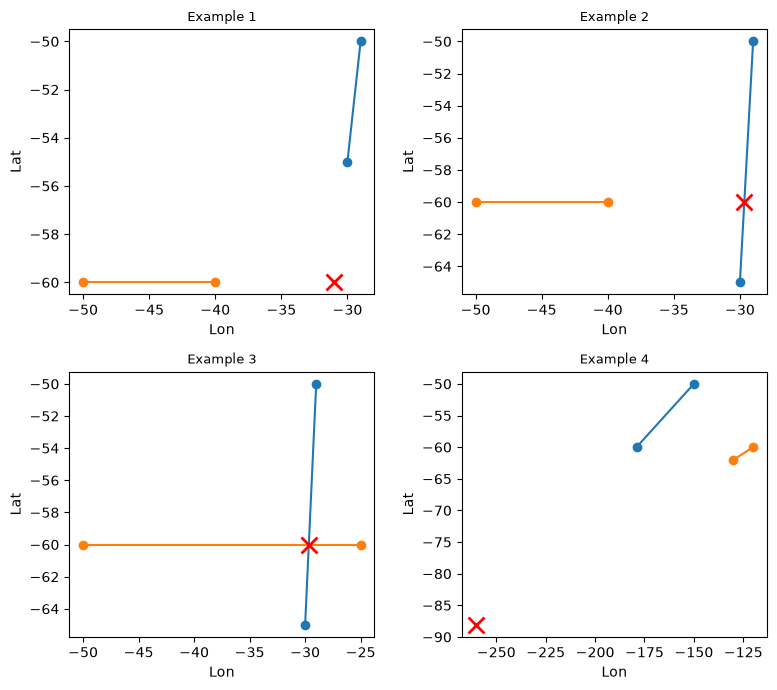

In [6]:
def plot_intersection(ax, line1, line2, title):
    x1, y1, x2, y2 = line1
    x3, y3, x4, y4 = line2
    result = cg.get_c_intersection(line1, line2)
    ax.plot([x1, x2], [y1, y2], marker="o")
    ax.plot([x3, x4], [y3, y4], marker="o")
    ax.plot(result["Lon"], result["Lat"], marker="x", color="red", markersize=12, markeredgewidth=2)
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# Example 1: intersection beyond the range of segments
plot_intersection(axes[0, 0], [-30, -55, -29, -50], [-50, -60, -40, -60], "Example 1")
# Example 2: intersection on one of the segments
plot_intersection(axes[0, 1], [-30, -65, -29, -50], [-50, -60, -40, -60], "Example 2")
# Example 3: crossed segments
plot_intersection(axes[1, 0], [-30, -65, -29, -50], [-50, -60, -25, -60], "Example 3")
# Example 4: antimeridian crossed
plot_intersection(axes[1, 1], [-179, -60, -150, -50], [-120, -60, -130, -62], "Example 4")

fig.tight_layout()
plt.show()

## 4.6. get_iso_polys

/Users/zephyrsylvester/miniforge3/envs/ccamlrgis-py/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


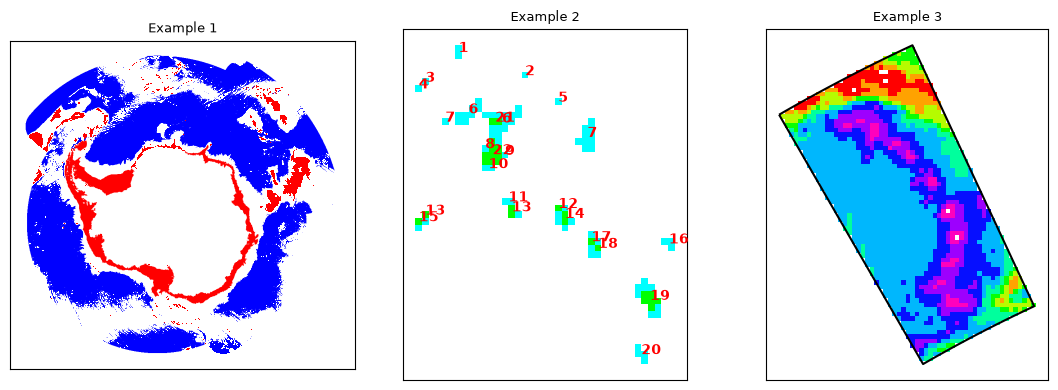

In [7]:
from matplotlib.colors import to_hex

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

# Example 1: whole Convention Area
iso_pols = cg.get_iso_polys(bathy_small, cuts=[-10000, -4000, -2000, 0], cols=["blue", "white", "red"])
ax = cgplot.basemap(ax=axes[0])[1]
iso_pols.plot(ax=ax, color=list(iso_pols["c"]))
ax.set_title("Example 1", fontsize=9)

# Example 2: SSRU 882H seamounts
ssrus = cg.load_ssrus()
poly_882h = ssrus[ssrus["GAR_Short_Label"] == "882H"]
iso_pols2 = cg.get_iso_polys(bathy_small, poly=poly_882h, cuts=[-2500, -1800, -600], cols=["cyan", "green"], grp=True)
ax = cgplot.basemap(ax=axes[1])[1]
iso_pols2.plot(ax=ax, color=list(iso_pols2["c"]))
for _, row in iso_pols2.iterrows():
    ax.annotate(row["Grp"], (row["Labx"], row["Laby"]), color="red", fontweight="bold", fontsize=10)
ax.set_title("Example 2", fontsize=9)

# Example 3: custom polygon
poly3 = cg.create_polys(pd.DataFrame({"ID": [1] * 4, "Lat": [-55, -55, -61, -61], "Lon": [-30, -25, -25, -30]}))
rainbow9 = [to_hex(c) for c in plt.cm.hsv(np.linspace(0, 1, 9, endpoint=False))]
iso_pols3 = cg.get_iso_polys(bathy_small, poly=poly3, cuts=np.linspace(-8000, 0, 10), cols=rainbow9)
ax = cgplot.basemap(ax=axes[2])[1]
poly3.boundary.plot(ax=ax, color="black")
iso_pols3.plot(ax=ax, color=list(iso_pols3["c"]))
ax.set_title("Example 3", fontsize=9)

fig.tight_layout()
plt.show()

## 4.7. rotate_obj

The R tutorial's `Rotate_obj` example is a 19-frame GIF (rotating through
`Lon0` values) -- out of scope for a notebook cell. A single rotated frame
below stands in for it.

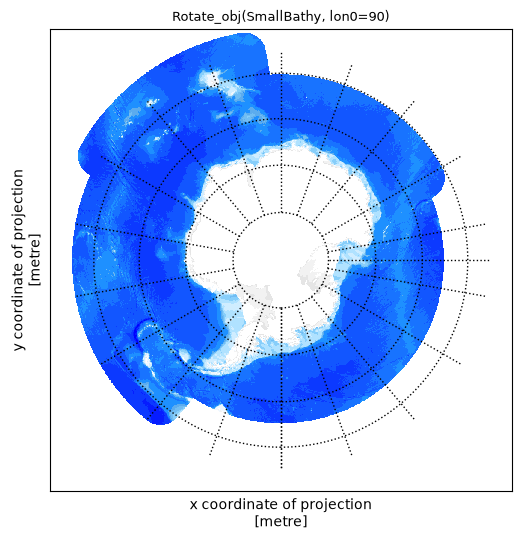

In [8]:
rotated = cg.rotate_obj(bathy_small, lon0=90)

fig, ax = plt.subplots(figsize=(6, 6))
cgplot.basemap(ax=ax)
rotated.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
cgplot.add_reference_grid(ax=ax, res_lat=10, res_lon=20, lab_lon=90)
ax.set_title("Rotate_obj(SmallBathy, lon0=90)", fontsize=9)
plt.show()